In [1]:
import pandas as pd
import numpy as np
import os
from sqlalchemy import create_engine, inspect

In [2]:
# Set up MySQL connection details
username = 'root'
password = 'Raisha789'
host = 'localhost'
port = 3306
database = 'superstor_db'

In [3]:
# Create SQLAlchemy engine for MySQL connection
engine = create_engine(f'mysql+pymysql://{username}:{password}@{host}:{port}/{database}')


In [4]:
conn = engine.connect()
conn

In [5]:
tables_df = pd.read_sql("show tables",conn)

In [6]:
tables_df

,Tables_in_superstor_db
0,cleaned_raw_data
1,customer_dim
2,product_dim
3,sales_fact
4,superstore_data


In [7]:
for table in tables_df['Tables_in_superstor_db']:
   df = pd.read_sql(f"Select * from {table};",conn)

In [8]:
print(f"\n Table Name : {table}")
print(df.head())


 Table Name : superstore_data
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156  11/08/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156  11/08/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688  06/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-C

In [9]:
df_customer = pd.read_sql("Select * from customer_dim;",conn)
df_sales = pd.read_sql("Select * from sales_fact;",conn)
df_product = pd.read_sql("Select * from product_dim;",conn)

#### EDA of Sales fact table , product and customer dimensional table 

In [10]:
tables = [df_customer, df_product, df_sales]

for table in tables:
    print(table.isnull().sum())

customer_id      0
customer_name    0
segment          0
country          0
city             0
state            0
postal_code      0
region           0
dtype: int64
product_id      0
category        0
sub_category    0
product_name    0
dtype: int64
order_id       0
order_date     0
ship_date      0
ship_mode      0
customer_id    0
product_id     0
sales          0
quantity       0
discount       0
profit         0
dtype: int64


In [11]:
tables = [df_customer, df_product, df_sales]

for table in tables:
    print(table.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4835 entries, 0 to 4834
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customer_id    4835 non-null   object
 1   customer_name  4835 non-null   object
 2   segment        4835 non-null   object
 3   country        4835 non-null   object
 4   city           4835 non-null   object
 5   state          4835 non-null   object
 6   postal_code    4835 non-null   int64 
 7   region         4835 non-null   object
dtypes: int64(1), object(7)
memory usage: 302.3+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1842 entries, 0 to 1841
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   product_id    1842 non-null   object
 1   category      1842 non-null   object
 2   sub_category  1842 non-null   object
 3   product_name  1842 non-null   object
dtypes: object(4)
memory usage: 57.7+ KB
None
<cl

In [12]:
tables = [df_customer, df_product, df_sales]

for table in tables:
    print(f"{table.shape}")

(4835, 8)
(1842, 4)
(9694, 10)


In [13]:
tables = [df_customer, df_product, df_sales]

for table in tables:
    print(table.duplicated().sum())

0
0
1


In [14]:
df_customer.head()

,customer_id,customer_name,segment,country,city,state,postal_code,region
0,cg-12520,claire gute,consumer,united states,henderson,kentucky,42420,south
1,dv-13045,darrin van huff,corporate,united states,los angeles,california,90036,west
2,so-20335,sean o'donnell,consumer,united states,fort lauderdale,florida,33311,south
3,bh-11710,brosina hoffman,consumer,united states,los angeles,california,90032,west
4,aa-10480,andrew allen,consumer,united states,concord,north carolina,28027,south


In [15]:
df_customer['country'].unique()

array(['united states'], dtype=object)

In [16]:
df_customer['state'].unique()

array(['kentucky', 'california', 'florida', 'north carolina',
       'washington', 'texas', 'wisconsin', 'utah', 'nebraska',
       'pennsylvania', 'illinois', 'minnesota', 'michigan', 'delaware',
       'indiana', 'new york', 'arizona', 'virginia', 'tennessee',
       'alabama', 'south carolina', 'oregon', 'colorado', 'iowa', 'ohio',
       'missouri', 'oklahoma', 'new mexico', 'louisiana', 'connecticut',
       'new jersey', 'massachusetts', 'georgia', 'nevada', 'rhode island',
       'mississippi', 'arkansas', 'montana', 'new hampshire', 'maryland',
       'district of columbia', 'kansas', 'vermont', 'maine',
       'south dakota', 'idaho', 'north dakota', 'wyoming',
       'west virginia'], dtype=object)

In [17]:
df_product.head()

,product_id,category,sub_category,product_name
0,fur-bo-10001798,furniture,bookcases,bush somerset collection bookcase
1,fur-ch-10000454,furniture,chairs,"hon deluxe fabric upholstered stacking chairs,..."
2,off-la-10000240,office supplies,labels,self-adhesive address labels for typewriters b...
3,fur-ta-10000577,furniture,tables,bretford cr4500 series slim rectangular table
4,off-st-10000760,office supplies,storage,eldon fold 'n roll cart system


In [18]:
df_sales.head()

,order_id,order_date,ship_date,ship_mode,customer_id,product_id,sales,quantity,discount,profit
0,ca-2016-152156,2016-11-08,2016-11-11,second class,cg-12520,fur-bo-10001798,261.96,2,0.00,41.9136
1,ca-2016-152156,2016-11-08,2016-11-11,second class,cg-12520,fur-ch-10000454,731.94,3,0.00,219.5820
2,ca-2016-138688,2016-06-12,2016-06-16,second class,dv-13045,off-la-10000240,14.62,2,0.00,6.8714
3,us-2015-108966,2015-10-11,2015-10-18,standard class,so-20335,fur-ta-10000577,957.58,5,0.45,-383.0310
4,us-2015-108966,2015-10-11,2015-10-18,standard class,so-20335,off-st-10000760,22.37,2,0.20,2.5164


In [19]:
df_sales.describe()

,sales,quantity,discount,profit
count,9694.000000,9694.000000,9694.000000,9694.000000
mean,234.418204,3.790902,0.155167,29.178645
std,631.789043,2.227335,0.204867,237.716804
min,0.440000,1.000000,0.000000,-6599.980000
25%,17.480000,2.000000,0.000000,1.735200
50%,55.930000,3.000000,0.200000,8.730750
75%,214.850000,5.000000,0.200000,30.009300
max,22638.480000,14.000000,0.800000,8399.980000


- Average sales is 234.41, 50% of sale happend around 55.93 and there are sales which max around 22638.4, Most orders are small, but a few bulk orders dominate revenue.
- average quantity order by per oreder is 4 and some orders purchase are around 14 qty most of the orders are small as we can see 75% of order is 5items
- Discounts are frequently used, and some heavy discounting occurs on selected orders.
- Average profit from the orders are 29 $ and for some purchase the profit has reached high that is 8399 might be a bulk order 

In [20]:
corr = df_sales[['sales','quantity','discount','profit']].corr() 

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

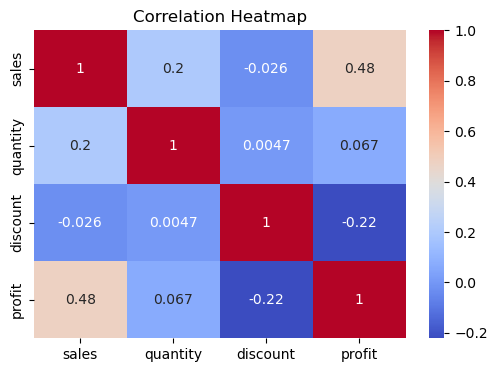

In [22]:
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

- Quantity and sales are weakly related, meaning pricing, discounts, and product type also influence sales.
- Sales and Quantity VS profit have a moderate positive relationship, indicating that increasing sales and quantity can usually improves profit, but not perfectly due to discounts and cost factors.
- Discounts are not dependent on quantity; they are likely based on product strategy or promotions and As discount increases, sales and profit tends to decrease slightly

### Predictive Analysis -Regression Technique 

#### STEP 1) Goal :- Profit Prediction 
   - since profit is slightly hurting by discount and slightly increase by quantity and sales
   - does actually discount is hurting 

#### STEP 2) Data collected from above tables are sales,quantity ,profit,discount,ship_mode,categoy and region

In [23]:
profit_predct = pd.read_sql("""
    SELECT 
        s.sales,
        s.quantity,
        s.profit, 
        s.discount,
        s.ship_mode,
        p.category,
        c.region
    FROM sales_fact AS s
    JOIN product_dim p ON s.product_id = p.product_id
    JOIN customer_dim c ON c.customer_id = s.customer_id;
""", conn)

In [24]:
profit_predct.head()

,sales,quantity,profit,discount,ship_mode,category,region
0,731.94,3,219.5820,0.00,second class,furniture,south
1,261.96,2,41.9136,0.00,second class,furniture,south
2,14.62,2,6.8714,0.00,second class,office supplies,west
3,22.37,2,2.5164,0.20,standard class,office supplies,south
4,957.58,5,-383.0310,0.45,standard class,furniture,south


### STEP 3) Data Preprocessing 

In [25]:
profit_predct.isnull().sum()

sales        0
quantity     0
profit       0
discount     0
ship_mode    0
category     0
region       0
dtype: int64

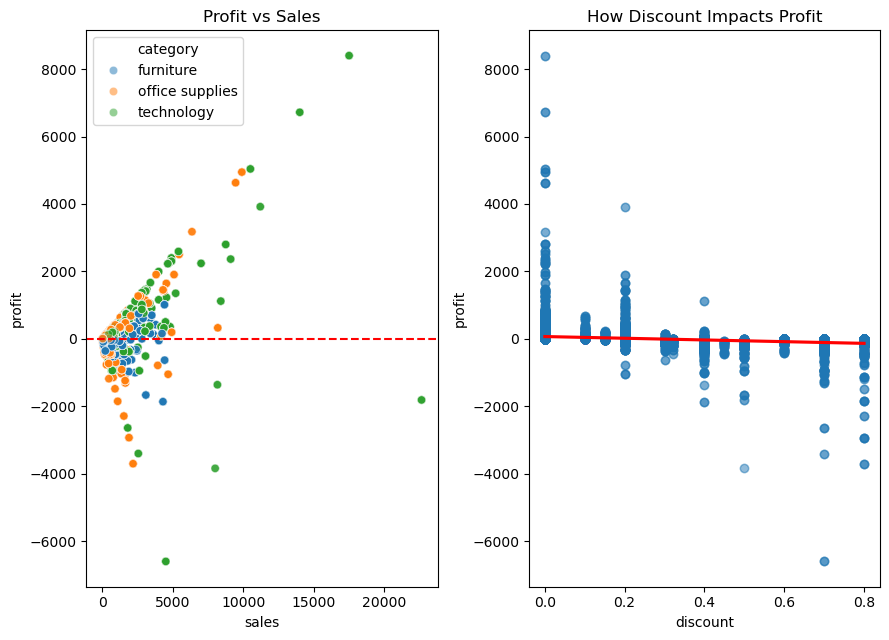

In [26]:
plt.figure(figsize=(9, 6.5))

# Plot 1: Profit vs Sales (Identifying high-value orders)
plt.subplot(1, 2, 1)
sns.scatterplot(data=profit_predct, x='sales', y='profit', hue='category', alpha=0.5)
plt.axhline(0, color='red', ls='--')
plt.title('Profit vs Sales')

# Plot 2: Profit vs Discount (Identifying the "Loss Point")
plt.subplot(1, 2, 2)
sns.regplot(data=profit_predct, x='discount', y='profit', 
            scatter_kws={'alpha':0.2}, line_kws={'color':'red'})
plt.title('How Discount Impacts Profit')

plt.tight_layout()
plt.show()

1) Graph 1: Profit vs. Sales :-
   - Most ofdots are in a tight cluster near the bottom left and some dots are high up so most of profit due to small amount sales and there with high profit
   - Some dots are at the bottom where there is huge loss sold for high price

2) Graph 2: Profit vs Discount :-
    - Line is slightly to downward less discount can save the profit and the more discount its actually hurting the profit

# STEP 4) Train and model :- the actual regression analysis start 
  - Target (Y): profitFeatures (X): discount, sales, quantity, category, region, ship_mode
  - Technique:- Regression Model.

In [27]:
# featuring
X = profit_predct[['sales', 'quantity', 'discount', 'category', 'region', 'ship_mode']]
y = profit_predct['profit']

X_encoded = pd.get_dummies(X, columns=['category', 'region', 'ship_mode'], drop_first=True)  #converting text to number encoding 

In [28]:
X_encoded.head()

,sales,quantity,discount,category_office supplies,category_technology,region_east,region_south,region_west,ship_mode_same day,ship_mode_second class,ship_mode_standard class
0,731.94,3,0.00,False,False,False,True,False,False,True,False
1,261.96,2,0.00,False,False,False,True,False,False,True,False
2,14.62,2,0.00,True,False,False,False,True,False,True,False
3,22.37,2,0.20,True,False,False,True,False,False,False,True
4,957.58,5,0.45,False,False,False,True,False,False,False,True


In [29]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# Split and train
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# modeling the train
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

## Prediction

In [30]:
#make prediction
y_preds = model.predict(X_test)

In [31]:
from sklearn.metrics import r2_score, mean_absolute_error

# step 5) Evaluation 

In [32]:
#model evaluation 
score = r2_score(y_test, y_preds)
error = mean_absolute_error(y_test, y_preds)

print(f"Accuracy : {score:.4f}")
print(f"error : {error}")

Accuracy : 0.9989
error : 1.4735715800524376


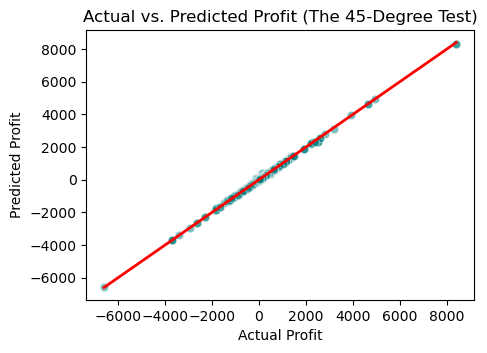

In [33]:
plt.figure(figsize=(5, 3.5))

# Plotting the Real Profit vs the Predicted Profit
sns.scatterplot(x=y_test, y=y_preds, alpha=0.5, color='teal')

# The "Perfect Match" line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)

plt.xlabel('Actual Profit')
plt.ylabel('Predicted Profit')
plt.title('Actual vs. Predicted Profit (The 45-Degree Test)')
plt.show()

In [34]:
# Create the comparison table using the test set index
comparison_df = profit_predct.loc[X_test.index].copy() # converted those binary to back human readable 
comparison_df['Predicted_Profit'] = y_preds

In [35]:
comparison_df.head()

,sales,quantity,profit,discount,ship_mode,category,region,Predicted_Profit
66303,43.44,8,21.2856,0.0,first class,office supplies,west,21.261800
23944,6.82,2,-11.5872,0.8,first class,office supplies,central,-11.407288
38122,47.12,8,20.7328,0.0,standard class,furniture,central,20.732800
68582,31.12,4,14.6264,0.0,standard class,office supplies,west,0.908172
63103,801.96,2,200.4900,0.0,standard class,furniture,south,200.490000


Our data proves that the biggest reason the company is losing money is because of high discounts. Even when we sell a lot of items , a big discount turns that success into a loss. Our AI model is 99% accurate, which means we are certain that high discounts are "killing" our profit. To fix this, the company must limit all discounts to 20% or less. By stopping these big discounts, especially on expensive items like Furniture, we can make sure every sale actually brings in money instead of losing it.

#### since discount is hurting most thought of Analysing category to choose one of it and analysis the actual vs predict profit 

In [36]:
category_df = comparison_df.groupby('category')[['sales','profit','discount']].mean()

In [37]:
category_df 

,sales,profit,discount
category,,,
furniture,344.912001,10.470069,0.170926
office supplies,123.459219,20.174266,0.158804
technology,444.789592,77.583279,0.136367


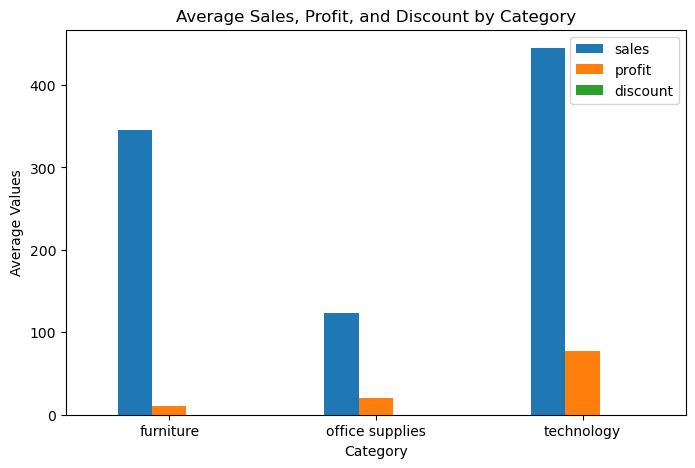

In [55]:
category_df.plot(kind='bar', figsize=(8,5))

# Titles and labels
plt.title('Average Sales, Profit, and Discount by Category')
plt.xlabel('Category')
plt.ylabel('Average Values')

# Rotate category names
plt.xticks(rotation=0)

# Show graph
plt.show()

- Technology seems healthy as sales is high profit is high
- office supplies is having low profit with low sales
- furniture has high sales but low profit 

#### from above insights of category will find the prediction with furniture 
- Since Furniture has has high sales and has low profit , thought to analysis is discount is intrepreting or other components 
- Possible business interpretation:Customers demand discounts for furniture products, so the company offers higher discounts to maintain sales volume.

In [39]:
# step 1  Filtering only from furniture 
furniture_df = comparison_df[
    comparison_df['category'] == 'furniture'
].copy()

In [40]:
#step 2 Select Features and Target
X = furniture_df[['sales', 'quantity', 'discount']]
y = furniture_df['profit']

In [41]:
#step 3 split and train 
X_train, X_test, y_train, y_test = train_test_split(  X, y, test_size=0.2, random_state=42)

In [42]:
#step 4 model the trained 
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [43]:
#step 4 predict the target 
y_pred = model.predict(X_test)

In [44]:
#step 5 validating and deploying 
from sklearn.metrics import r2_score, mean_absolute_error

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2 Score: 0.3603681260214111
MAE: 50.49305482114359


In [45]:
compare_fur = pd.DataFrame({
    'Actual Profit': y_test.values,
    'Predicted Profit': y_pred
}).reset_index(drop=True)

In [46]:
compare_fur.head(10)

,Actual Profit,Predicted Profit
0,-31.3722,-38.185923
1,50.0980,18.346683
2,10.9602,-11.486428
3,-77.6250,-139.673892
4,31.4548,69.196462
5,10.4148,52.608740
6,-12.8784,12.435930
7,30.7818,53.933150
8,-32.3673,26.280760
9,75.7350,64.106446


In [47]:
result = X_test.copy()
result['Actual_Profit'] = y_test.values
result['Predicted_Profit'] = y_pred

In [48]:
result.head()

,sales,quantity,discount,Actual_Profit,Predicted_Profit
32732,244.01,2,0.30,-31.3722,-38.185923
18597,801.57,2,0.20,50.0980,18.346683
66007,97.42,2,0.20,10.9602,-11.486428
60507,103.50,5,0.60,-77.6250,-139.673892
14069,1336.83,13,0.15,31.4548,69.196462


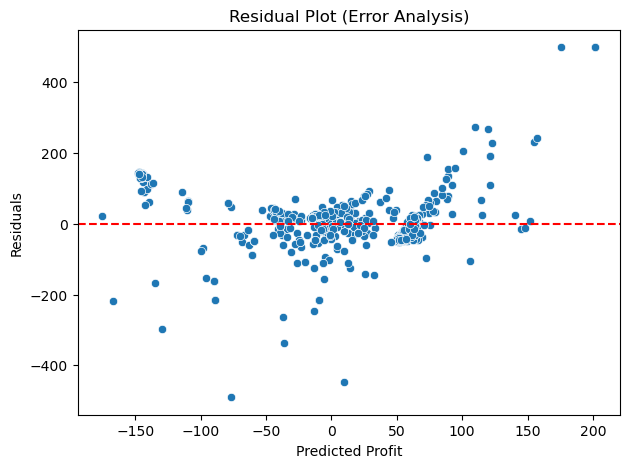

In [60]:
# 2. Residual Plot
plt.figure(figsize=(7, 5))
residuals = y_test - y_pred
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residual Plot (Error Analysis)')
plt.xlabel('Predicted Profit')
plt.ylabel('Residuals')
plt.show()

#### Discount impact is inconsistent and highly dependent on other compenent , where the same discount level can lead to profit in some cases and loss in others.

#### BY Taking 2 type of sample low and high sale and simulating with different discount value to predict the impact on profit 

In [49]:
low_threshold = result['sales'].quantile(0.33)

In [50]:
low_sale_sample = result[result['sales']<=low_threshold].sample(1)

In [51]:
low_test = pd.DataFrame ({
    'sales':[low_sale_sample['sales'].values[0]] * 5,
    'quantity' :[low_sale_sample['quantity'].values[0]]*5,
    'discount' : [0.0,0.1,0.2,0.3,0.4]
})

In [52]:
low_test['Predicted_Profit'] = model.predict(low_test)

In [53]:
low_test

,sales,quantity,discount,Predicted_Profit
0,44.46,2,0.0,52.090096
1,44.46,2,0.1,19.179941
2,44.46,2,0.2,-13.730213
3,44.46,2,0.3,-46.640367
4,44.46,2,0.4,-79.550522


In [54]:
high_threshold = result['sales'].quantile(0.66)

high_sale_sample = result[result['sales']<=high_threshold].sample(1)

high_test = pd.DataFrame ({
    'sales':[high_sale_sample['sales'].values[0]] * 5,
    'quantity' :[high_sale_sample['quantity'].values[0]]*5,
    'discount' : [0.0,0.1,0.2,0.3,0.4]
})

high_test['Predicted_Profit'] = model.predict(high_test)

high_test

,sales,quantity,discount,Predicted_Profit
0,19.54,2,0.0,51.034296
1,19.54,2,0.1,18.124142
2,19.54,2,0.2,-14.786012
3,19.54,2,0.3,-47.696167
4,19.54,2,0.4,-80.606321


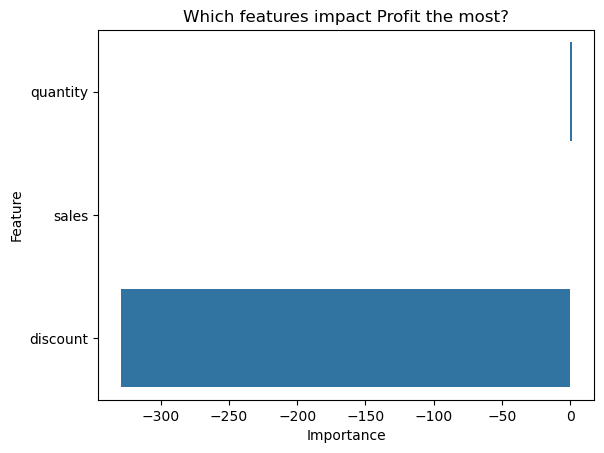

In [59]:
# 3. Feature Importance
coefficients = pd.DataFrame({'Feature': X.columns, 'Importance': model.coef_})
coefficients = coefficients.sort_values(by='Importance', ascending=False)
sns.barplot(x='Importance', y='Feature', data=coefficients)
plt.title('Which features impact Profit the most?')
plt.show()

###  So yes after taking of 5 different sample of discount the increases in discount, predicted profit consistently decreases and eventually turns negative.

### this doesn't mean applying discount is bad but we need take action as to get new orders and attract a customer 

### Final Recommondation 
1. Customer Segmentation (RFM Analysis) :- Identify high-value customers and reduce unnecessary discounting for them.
2. Market Basket / Combo Strategy
3. Discount Optimization
4. Category-Level Strategy
   - Technology: Maintain current strategy (healthy)
   - Office Supplies: Focus on increasing demand
   - Furniture: Reduce discount dependency, redesign pricing strategy